# Duo patches model for clean and faulty

*Idea is to feed images, split them by grid into 6 parts, identify whether there are any dead keys at all or mixed colour key <br>*
*If every patch of an image returns clean --> image is clean, otherwise any single patch returns faulty --> image returns faulty*

# 1. Exploratory Data Analysis

In [2]:
from pathlib import Path

# Defining directories
base_dir = Path.home() / "Documents" / "duo_patches_dataset"
patches_dir = Path.home() / "Documents" / "duo_patches_dataset" / "patches"
raw_images_dir = Path.home() / "Documents" / "duo_patches_dataset" / "raw_images"

base_dir

WindowsPath('C:/Users/Yin Yu/Documents/duo_patches_dataset')

## Splitting data (batching them through cropping)
### Do not run if already split! Duplicates/ overwrite.

### For clean images

In [ ]:
import cv2
import os

def crop_image_to_patches(img_path, output_dir, label, rows=2, cols=3, size=224):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read {img_path}")
        return
    h, w = img.shape[:2]
    patch_h, patch_w = h // rows, w // cols

    base_name = os.path.splitext(os.path.basename(img_path))[0]

    for i in range(rows):
        for j in range(cols):
            y1, y2 = i * patch_h, (i + 1) * patch_h
            x1, x2 = j * patch_w, (j + 1) * patch_w
            patch = img[y1:y2, x1:x2]
            resized = cv2.resize(patch, (size, size))
            patch_name = f"{base_name}_r{i}_c{j}.jpg"
            save_path = os.path.join(output_dir, label, patch_name)
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            cv2.imwrite(save_path, resized)

source_dir = raw_images_dir
output_dir = patches_dir

for label in ['clean__']:  # change to correct file name when needed; already split.
    image_dir = os.path.join(source_dir, label)
    for filename in os.listdir(image_dir):
        img_path = os.path.join(image_dir, filename)
        crop_image_to_patches(img_path, output_dir, label)

### For faulty images

In [4]:
import cv2
import os

def crop_image_to_patches(img_path, output_dir, label, rows=2, cols=3, size=224):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read {img_path}")
        return
    h, w = img.shape[:2]
    patch_h, patch_w = h // rows, w // cols

    base_name = os.path.splitext(os.path.basename(img_path))[0]

    for i in range(rows):
        for j in range(cols):
            y1, y2 = i * patch_h, (i + 1) * patch_h
            x1, x2 = j * patch_w, (j + 1) * patch_w
            patch = img[y1:y2, x1:x2]
            resized = cv2.resize(patch, (size, size))
            patch_name = f"{base_name}_r{i}_c{j}.jpg"
            save_path = os.path.join(output_dir, label, patch_name)
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            cv2.imwrite(save_path, resized)

source_dir = raw_images_dir
output_dir = patches_dir

for label in ['complete_faulty']:  # change to correct file name when needed; already split.
    image_dir = os.path.join(source_dir, label)
    for filename in os.listdir(image_dir):
        img_path = os.path.join(image_dir, filename)
        crop_image_to_patches(img_path, output_dir, label)

Visualization

In [2]:
from pathlib import Path

# Define the patch folder path
patches_dir = Path.home() / "Documents" / "duo_patches_dataset" / "patches"
subfolders = ["clean", "faulty"]

# Store results
class_counts = {}
total_counts = {}

# Count images directly in each folder
for sub in subfolders:
    data_path = patches_dir / sub
    image_files = list(data_path.glob("*.*"))
    class_counts[sub] = len(image_files)
    total_counts[sub] = len(image_files)

# Print results
for sub in subfolders:
    print(f"{sub}: {class_counts[sub]}")


clean: 900
faulty: 600


Split to train and validation sets, will collect test sets again due to low number of images

In [13]:
import os
import shutil
import random
from pathlib import Path

def split_dataset(patches_dir, output_dir, train_ratio=0.8, seed=42):
    random.seed(seed)
    for label in ['clean', 'faulty']:
        src_folder = Path(patches_dir) / label
        files = list(src_folder.glob("*.*"))
        random.shuffle(files)

        n_total = len(files)
        n_train = int(n_total * train_ratio)
        train_files = files[:n_train]
        val_files = files[n_train:]

        for split_name, split_files in [('train', train_files), ('val', val_files)]:
            for file_path in split_files:
                dest = Path(output_dir) / split_name / label / file_path.name
                os.makedirs(dest.parent, exist_ok=True)
                shutil.copy2(file_path, dest)

split_dataset(
    patches_dir = Path.home() / "Documents" / "duo_patches_dataset" / "patches",
    output_dir= Path.home() / "Documents" / "duo_patches_dataset" / "split_data",
    train_ratio=0.8
)


Visualize the number of images in each folders

In [3]:
from pathlib import Path

output_dir = Path.home() / "Documents" / "duo_patches_dataset" / "split_data"
splits = ["train", "val"]
subfolders = ["clean", "faulty"]

# Store results
split_counts = {}

# Loop through train and val
for split in splits:
    split_dir = output_dir / split
    split_counts[split] = {}

    for sub in subfolders:
        data_path = split_dir / sub
        image_files = list(data_path.glob("*.*"))
        split_counts[split][sub] = len(image_files)

# Print results
for split in splits:
    print(f"\n {split.upper()} SPLIT:")
    for sub in subfolders:
        print(f"  {sub}: {split_counts[split][sub]}")


 TRAIN SPLIT:
  clean: 720
  faulty: 474

 VAL SPLIT:
  clean: 180
  faulty: 116


# 2. Data Augmentation

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

output_dir = Path.home() / "Documents" / "duo_patches_dataset" / "split_data"
train_dir = output_dir / "train"
val_dir = output_dir / "val"

train_datagen = ImageDataGenerator(
    rescale=1./255,             # normalization
    rotation_range=20,          # mild rotations (since already did up to 360)
    brightness_range=[0.9, 1.1],  # small brightness tweaks
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=5,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation for val

train_generator = train_datagen.flow_from_directory(
    directory=str(train_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    directory=str(val_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

Found 1194 images belonging to 2 classes.
Found 296 images belonging to 2 classes.


In [5]:
print("Class Indices (One-Hot Mapping):")
print(train_generator.class_indices)

Class Indices (One-Hot Mapping):
{'clean': 0, 'faulty': 1}


# 3. Model Training

### Sequential

In [20]:
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import math
import numpy as np
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])

loss = 'binary_crossentropy'

# Compile Model
model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_path = "../models/checkpoints/binary_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False 
)

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=20,
    validation_data=val_generator,
    validation_steps = math.ceil(val_generator.samples / val_generator.batch_size),
    callbacks=[early_stopping, checkpoint_cb],
)

# Load the best model (based on val_loss)
best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(val_generator)
print(f"Best Validation Loss: {val_loss}")
print(f"Best Validation Accuracy: {val_accuracy}")

best_model.save('../models/patches_model.h5')

parent_dir = Path.cwd().parent

metrics_path = os.path.join(parent_dir, "metrics")
os.makedirs(metrics_path, exist_ok=True)

subfolder_path = os.path.join(metrics_path, "multiclass_duo")
os.makedirs(subfolder_path, exist_ok=True)

with open(os.path.join(metrics_path, "multiclass_duo/patches.json"), "w") as f:
    json.dump(history.history, f)

Epoch 1/20
38/38 [==============================] - 26s 632ms/step - loss: 0.7944 - accuracy: 0.5900 - val_loss: 0.6377 - val_accuracy: 0.6000
Epoch 2/20
38/38 [==============================] - 8s 205ms/step - loss: 0.6471 - accuracy: 0.6342 - val_loss: 0.5788 - val_accuracy: 0.7167
Epoch 3/20
38/38 [==============================] - 8s 207ms/step - loss: 0.6297 - accuracy: 0.6450 - val_loss: 0.5491 - val_accuracy: 0.7100
Epoch 4/20
38/38 [==============================] - 7s 192ms/step - loss: 0.6092 - accuracy: 0.6775 - val_loss: 0.5737 - val_accuracy: 0.7100
Epoch 5/20
38/38 [==============================] - 8s 207ms/step - loss: 0.6173 - accuracy: 0.6600 - val_loss: 0.5368 - val_accuracy: 0.7733
Epoch 6/20
38/38 [==============================] - 8s 213ms/step - loss: 0.6042 - accuracy: 0.6858 - val_loss: 0.5051 - val_accuracy: 0.7867
Epoch 7/20
38/38 [==============================] - 7s 187ms/step - loss: 0.6018 - accuracy: 0.6792 - val_loss: 0.5595 - val_accuracy: 0.7667
Epoch

### Transfer Learning

In [27]:
import os
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import math
import numpy as np
import json
import tensorflow as tf

img_size = 224
batch_size = 32

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False
model = models.Sequential([
    base_model,  
    layers.GlobalAveragePooling2D(),  
    layers.Dense(128, activation='relu'), 
    layers.Dropout(0.5),  
    layers.Dense(1, activation='sigmoid') 
])

# loss = 'binary_crossentropy'

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_mean(alpha * tf.math.pow(1. - pt_1, gamma) * tf.math.log(pt_1)) - \
               tf.reduce_mean((1 - alpha) * tf.math.pow(pt_0, gamma) * tf.math.log(1. - pt_0))
    return loss

# Compile Model
model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_path = "../models/checkpoints/binary_best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False 
)

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=20,
    validation_data=val_generator,
    validation_steps = math.ceil(val_generator.samples / val_generator.batch_size),
    callbacks=[early_stopping, checkpoint_cb],
)

# Load the best model (based on val_loss)
# best_model = tf.keras.models.load_model(checkpoint_path)

best_model = tf.keras.models.load_model(
    checkpoint_path,
    custom_objects={'loss': focal_loss()}
)

# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(val_generator)
print(f"Best Validation Loss: {val_loss}")
print(f"Best Validation Accuracy: {val_accuracy}")

best_model.save('../models/patches_model2.h5')

parent_dir = Path.cwd().parent

metrics_path = os.path.join(parent_dir, "metrics")
os.makedirs(metrics_path, exist_ok=True)

subfolder_path = os.path.join(metrics_path, "multiclass_duo")
os.makedirs(subfolder_path, exist_ok=True)

with open(os.path.join(metrics_path, "multiclass_duo/patches2.json"), "w") as f:
    json.dump(history.history, f)

Epoch 1/20
38/38 [==============================] - 9s 203ms/step - loss: 0.1042 - accuracy: 0.5963 - val_loss: 0.0597 - val_accuracy: 0.6216
Epoch 2/20
38/38 [==============================] - 7s 195ms/step - loss: 0.0667 - accuracy: 0.6164 - val_loss: 0.0599 - val_accuracy: 0.6284
Epoch 3/20
38/38 [==============================] - 7s 190ms/step - loss: 0.0628 - accuracy: 0.6290 - val_loss: 0.0576 - val_accuracy: 0.6216
Epoch 4/20
38/38 [==============================] - 7s 190ms/step - loss: 0.0634 - accuracy: 0.6415 - val_loss: 0.0565 - val_accuracy: 0.6182
Epoch 5/20
38/38 [==============================] - 7s 194ms/step - loss: 0.0600 - accuracy: 0.6382 - val_loss: 0.0553 - val_accuracy: 0.6689
Epoch 6/20
38/38 [==============================] - 7s 196ms/step - loss: 0.0603 - accuracy: 0.6583 - val_loss: 0.0557 - val_accuracy: 0.6723
Epoch 7/20
38/38 [==============================] - 7s 194ms/step - loss: 0.0581 - accuracy: 0.6868 - val_loss: 0.0523 - val_accuracy: 0.6554
Epoch 

In [29]:
import os
import json
import math
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils import class_weight
import numpy as np

# === Paths ===
model_path = "../models/patches_model2.h5"
checkpoint_path = "../models/checkpoints/finetuned_model.h5"
final_model_path = "../models/patches_model_finetuned.h5"
metrics_path = Path("../metrics/multiclass_duo")
metrics_path.mkdir(parents=True, exist_ok=True)

# === Load and Prepare Model ===
# model = load_model(model_path)
model = tf.keras.models.load_model(
    model_path,
    custom_objects={'loss': focal_loss()}
)
base_model = model.layers[0]  # MobileNetV2
base_model.trainable = True

# Freeze lower layers, fine-tune only top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# === Compile for Fine-Tuning ===
model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

patch_labels = train_generator.classes  # This works if you're using ImageDataGenerator
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(patch_labels),
    y=patch_labels
)
class_weights = dict(enumerate(weights))

# === Callbacks ===
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# === Train ===
history = model.fit(
    train_generator,
    class_weight=class_weights,
    steps_per_epoch=math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=20,
    validation_data=val_generator,
    validation_steps=math.ceil(val_generator.samples / val_generator.batch_size),
    callbacks=[checkpoint_cb, early_stopping]
)

# === Evaluate Best Model ===
best_refined_model = tf.keras.models.load_model(checkpoint_path)
val_loss, val_accuracy = best_refined_model.evaluate(val_generator)
print(f"Best Validation Loss: {val_loss:.4f}")
print(f"Best Validation Accuracy: {val_accuracy:.4f}")

# === Save Final Model and Metrics ===
best_refined_model.save(final_model_path)
with open(metrics_path / "patches2_finetuned.json", "w") as f:
    json.dump(history.history, f)


Epoch 1/20
38/38 [==============================] - 10s 212ms/step - loss: 0.6359 - accuracy: 0.6524 - val_loss: 0.5290 - val_accuracy: 0.7534
Epoch 2/20
38/38 [==============================] - 8s 202ms/step - loss: 0.5801 - accuracy: 0.7010 - val_loss: 0.5187 - val_accuracy: 0.7703
Epoch 3/20
38/38 [==============================] - 8s 209ms/step - loss: 0.5569 - accuracy: 0.7504 - val_loss: 0.5083 - val_accuracy: 0.7736
Epoch 4/20
38/38 [==============================] - 8s 206ms/step - loss: 0.5342 - accuracy: 0.7538 - val_loss: 0.4971 - val_accuracy: 0.7804
Epoch 5/20
38/38 [==============================] - 8s 208ms/step - loss: 0.5308 - accuracy: 0.7563 - val_loss: 0.4902 - val_accuracy: 0.7838
Epoch 6/20
38/38 [==============================] - 8s 207ms/step - loss: 0.5088 - accuracy: 0.7714 - val_loss: 0.4795 - val_accuracy: 0.7770
Epoch 7/20
38/38 [==============================] - 8s 205ms/step - loss: 0.4921 - accuracy: 0.7772 - val_loss: 0.4721 - val_accuracy: 0.7838
Epoch

# 4. Model Evaluation

1/1 [==============================] - 0s 392ms/step


C:\Users\Yin Yu\AppData\Local\Temp\ipykernel_22268\3152692698.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_score = float(y_pred_batch[idx])


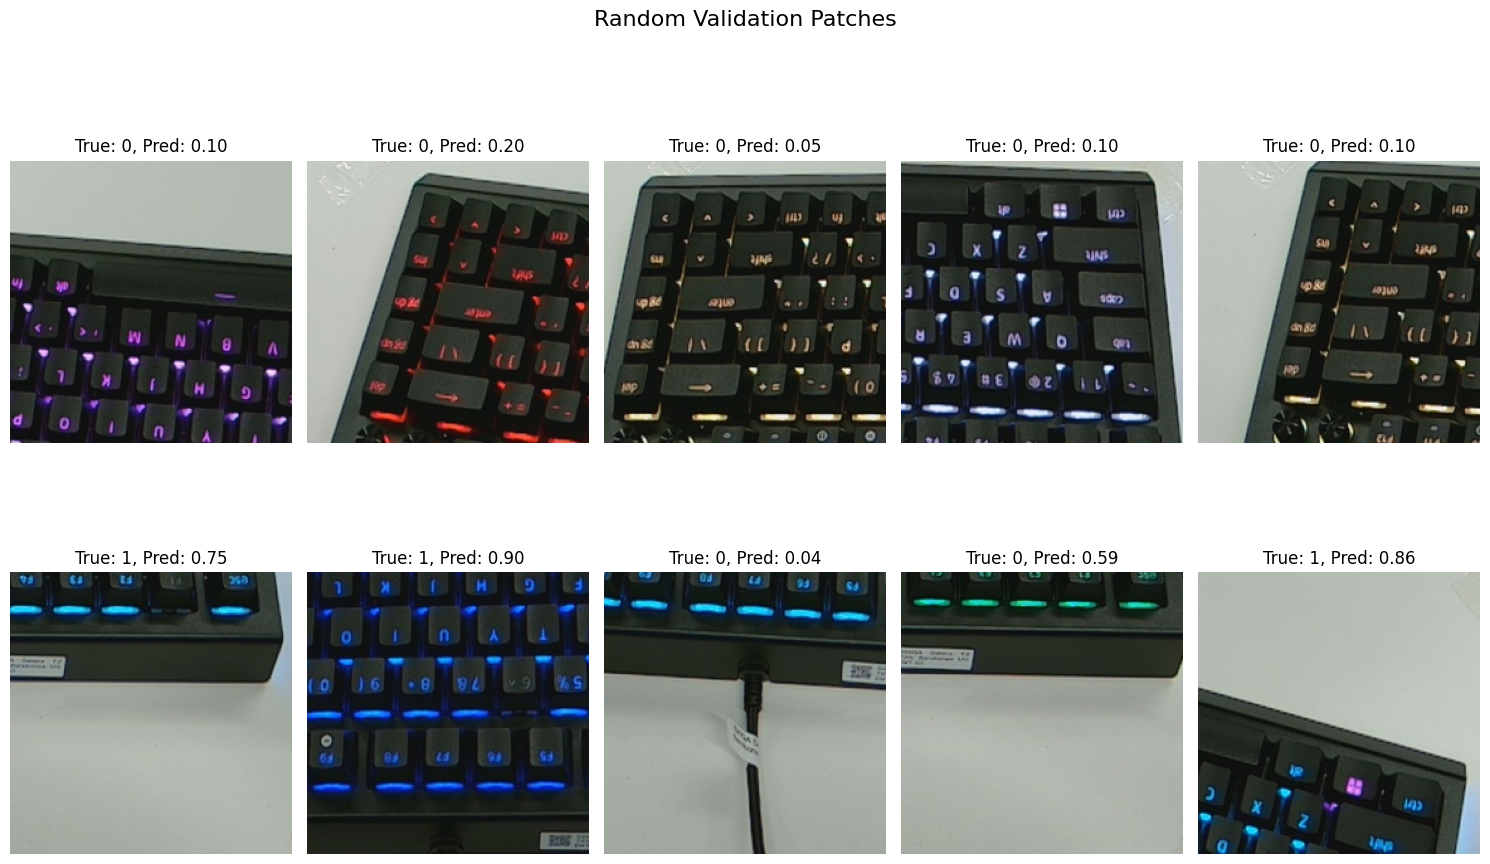

In [9]:
import matplotlib.pyplot as plt
import random
import numpy as np
import tensorflow as tf

# === Fetch a random batch from the validation generator ===
x_val_batch, y_val_batch = next(val_generator)

# === Predict on that batch ===
checkpoint_path = "../models/checkpoints/finetuned_model.h5"
best_refined_model = tf.keras.models.load_model(checkpoint_path)
y_pred_batch = best_refined_model.predict(x_val_batch)

# === Select a few random indices ===
num_to_show = 10
indices = random.sample(range(len(x_val_batch)), num_to_show)

# === Plot patches with predictions ===
plt.figure(figsize=(15, 10))
for i, idx in enumerate(indices):
    img = x_val_batch[idx]
    true_label = int(y_val_batch[idx])
    pred_score = float(y_pred_batch[idx])

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {true_label}, Pred: {pred_score:.2f}", fontsize=12)

plt.suptitle("Random Validation Patches", fontsize=16)
plt.tight_layout()
plt.show()

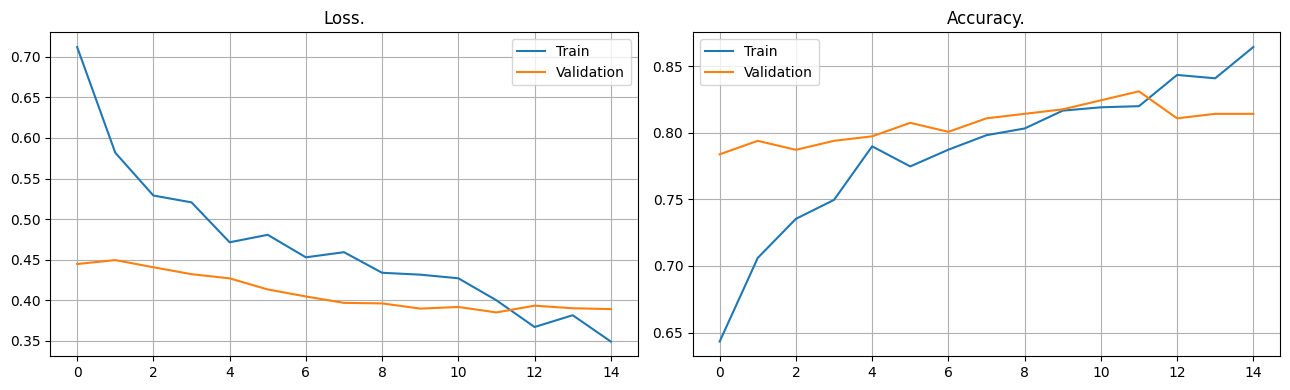

In [4]:
# Extracting metrics

import matplotlib.pyplot as plt

metrics = history.history

train_loss = metrics["loss"]
train_accuracy = metrics["accuracy"]

validation_loss = metrics["val_loss"]
validation_accuracy = metrics["val_accuracy"]

# Visualizing metrics
plt.figure(figsize = (13,4))
plt.subplot(1,2,1)
plt.title("Loss.")
plt.plot(train_loss, label = "Train")
plt.plot(validation_loss, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

plt.subplot(1,2,2)
plt.title("Accuracy.")
plt.plot(train_accuracy, label = "Train")
plt.plot(validation_accuracy, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

# Save the figure
plt.tight_layout()
plt.savefig("../metrics/multiclass_duo/patches_finetuned.png")
plt.show()
plt.close()

# For test dataset; metrics, etc

test_clean_1.jpg | Patch (0,0) | Prediction: 0.3930
test_clean_1.jpg | Patch (0,1) | Prediction: 0.1153
test_clean_1.jpg | Patch (0,2) | Prediction: 0.4950
test_clean_1.jpg | Patch (1,0) | Prediction: 0.3554
test_clean_1.jpg | Patch (1,1) | Prediction: 0.2287
test_clean_1.jpg | Patch (1,2) | Prediction: 0.7362
test_clean_1.jpg: Mean Adjusted Score = 0.3218
test_clean_1.jpg: Predicted=0, Actual=0
test_clean_10.jpg | Patch (0,0) | Prediction: 0.2590
test_clean_10.jpg | Patch (0,1) | Prediction: 0.0650
test_clean_10.jpg | Patch (0,2) | Prediction: 0.2108
test_clean_10.jpg | Patch (1,0) | Prediction: 0.0912
test_clean_10.jpg | Patch (1,1) | Prediction: 0.0784
test_clean_10.jpg | Patch (1,2) | Prediction: 0.5995
test_clean_10.jpg: Mean Adjusted Score = 0.1515
test_clean_10.jpg: Predicted=0, Actual=0
test_clean_11.jpg | Patch (0,0) | Prediction: 0.8715
test_clean_11.jpg | Patch (0,1) | Prediction: 0.6342
test_clean_11.jpg | Patch (0,2) | Prediction: 0.6711
test_clean_11.jpg | Patch (1,0) | P

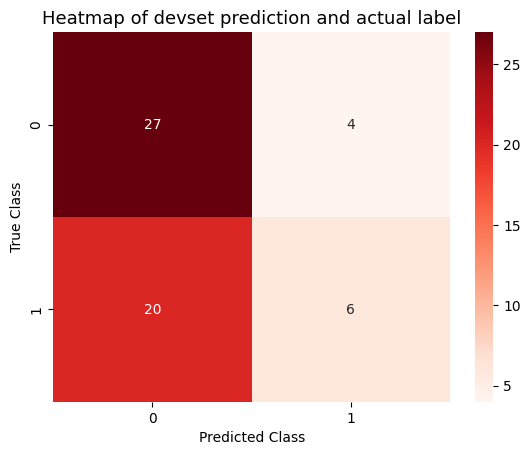


Classification Report:
              precision    recall  f1-score   support

       Clean       0.57      0.87      0.69        31
      Faulty       0.60      0.23      0.33        26

    accuracy                           0.58        57
   macro avg       0.59      0.55      0.51        57
weighted avg       0.59      0.58      0.53        57



In [10]:
from pathlib import Path
import tensorflow as tf
import numpy as np
import cv2

img_size = 224
# threshold = 0.82
rows, cols = 2, 3

# Load model
model = tf.keras.models.load_model('../models/patches_model_finetuned.h5')

# def predict_grid_image(img_path):
#     img = cv2.imread(str(img_path))
#     h, w = img.shape[:2]
#     patch_h, patch_w = h // rows, w // cols

#     for i in range(rows):
#         for j in range(cols):
#             y1, y2 = i * patch_h, (i + 1) * patch_h
#             x1, x2 = j * patch_w, (j + 1) * patch_w
#             patch = img[y1:y2, x1:x2]
#             patch_resized = cv2.resize(patch, (img_size, img_size))
#             patch_resized = patch_resized.astype('float32') / 255.0
#             patch_input = np.expand_dims(patch_resized, axis=0)
#             pred = model.predict(patch_input, verbose=0)[0][0]
#             print(f"{img_path.name} | Patch ({i},{j}) | Prediction: {pred:.4f}")

#             if pred >= threshold:
#                 return 1  # faulty
#     return 0  # clean

def predict_grid_image(img_path, threshold=0.55):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    patch_h, patch_w = h // rows, w // cols
    patch_scores = []

    for i in range(rows):
        for j in range(cols):
            y1, y2 = i * patch_h, (i + 1) * patch_h
            x1, x2 = j * patch_w, (j + 1) * patch_w
            patch = img[y1:y2, x1:x2]
            patch_resized = cv2.resize(patch, (img_size, img_size))
            patch_resized = patch_resized.astype('float32') / 255.0
            patch_input = np.expand_dims(patch_resized, axis=0)
            pred = model.predict(patch_input, verbose=0)[0][0]
            patch_scores.append(pred)
            print(f"{img_path.name} | Patch ({i},{j}) | Prediction: {pred:.4f}")

    # Apply sigmoid sharpening to each patch score
    adjusted_scores = tf.nn.sigmoid(10 * (np.array(patch_scores) - 0.5)).numpy()
    mean_score = np.mean(adjusted_scores)
    print(f"{img_path.name}: Mean Adjusted Score = {mean_score:.4f}")

    return 1 if mean_score > threshold else 0


# Paths
test_dir = Path.home() / "Documents" / "duo_patches_dataset" / "split_data" / "test"
categories = ['clean', 'faulty']

# Evaluate
y_true = []
y_pred = []

for label in categories:
    label_path = test_dir / label
    for img_path in label_path.glob("*.jpg"):
        true_label = 0 if label == 'clean' else 1
        pred_label = predict_grid_image(img_path)
        y_true.append(true_label)
        y_pred.append(pred_label)
        print(f"{img_path.name}: Predicted={pred_label}, Actual={true_label}")

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Calculating confusion matrix
plt.title("Heatmap of devset prediction and actual label", fontsize = 13)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, cmap = "Reds", annot = True, fmt = "d")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")

# Save heatmap image
plt.savefig("../metrics/multiclass_duo/patches_finedtuned_heatmap.png")
plt.show()
plt.close()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Clean', 'Faulty']))

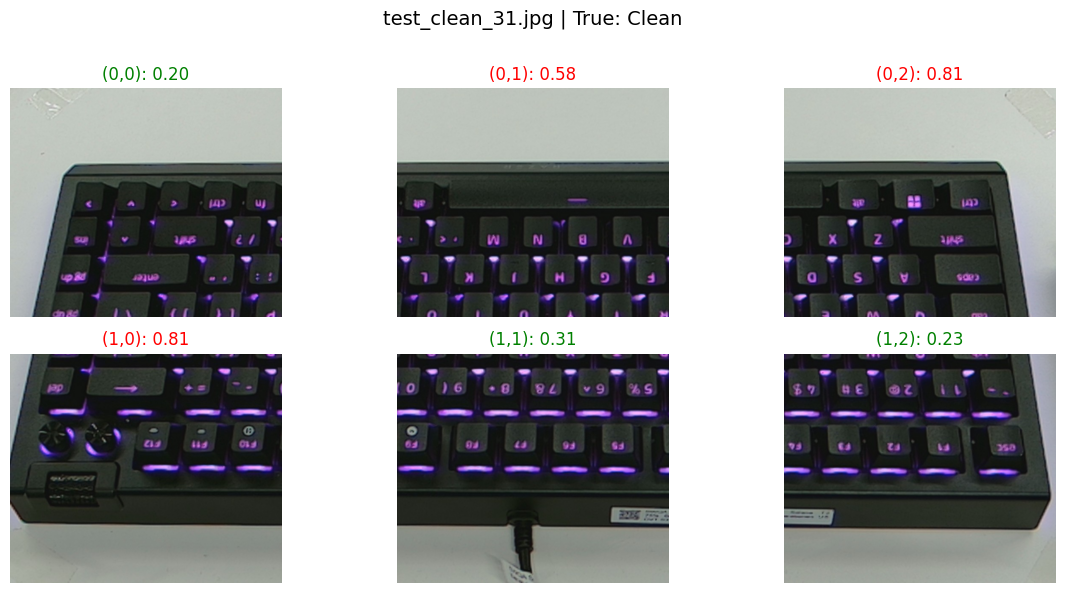

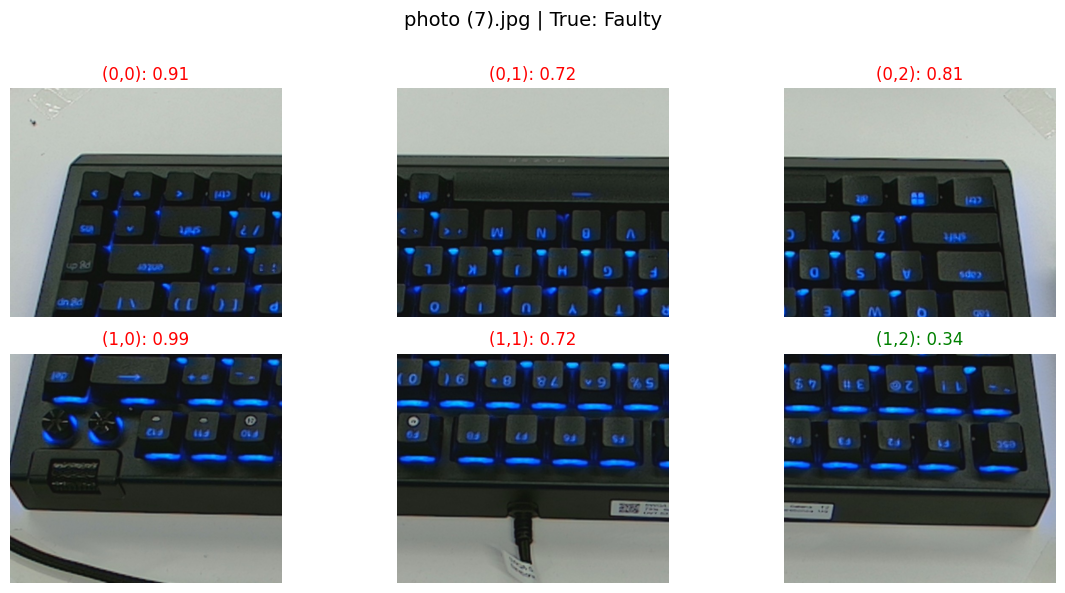

[0.9069284, 0.7193599, 0.8119235, 0.98880005, 0.7235091, 0.3426603]

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_patches_with_predictions(img_path, model, true_label, rows=2, cols=3, threshold=0.5):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    patch_h, patch_w = h // rows, w // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig.suptitle(f"{img_path.name} | True: {'Faulty' if true_label == 1 else 'Clean'}", fontsize=14)

    patch_scores = []

    for i in range(rows):
        for j in range(cols):
            y1, y2 = i * patch_h, (i + 1) * patch_h
            x1, x2 = j * patch_w, (j + 1) * patch_w
            patch = img_rgb[y1:y2, x1:x2]
            patch_resized = cv2.resize(patch, (img_size, img_size))
            patch_input = patch_resized.astype('float32') / 255.0
            patch_input = np.expand_dims(patch_input, axis=0)
            pred = model.predict(patch_input, verbose=0)[0][0]
            patch_scores.append(pred)

            axes[i][j].imshow(patch)
            axes[i][j].axis('off')
            axes[i][j].set_title(f"({i},{j}): {pred:.2f}", color="red" if pred >= threshold else "green")

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

    return patch_scores

import random

# Assuming your test_dir structure has 'clean' and 'faulty' subfolders
clean_imgs = list((test_dir / "clean").glob("*.jpg"))
faulty_imgs = list((test_dir / "faulty").glob("*.jpg"))

# Pick one random image from each category
random_clean = random.choice(clean_imgs)
random_faulty = random.choice(faulty_imgs)

# Show their patches with predictions
visualize_patches_with_predictions(random_clean, model, true_label=0)
visualize_patches_with_predictions(random_faulty, model, true_label=1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import random
from pathlib import Path
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array

img_size = 224
rows, cols = 2, 3
model_path = "../models/patches_model_finetuned.h5"
model = tf.keras.models.load_model(model_path)

def get_random_image(path):
    images = list(Path(path).glob("*.jpg"))
    return random.choice(images)

def preprocess_patch(patch):
    patch_resized = cv2.resize(patch, (img_size, img_size))
    patch_normalized = patch_resized.astype('float32') / 255.0
    return np.expand_dims(patch_normalized, axis=0)

def compute_gradcam(patch_array, model, last_conv_layer_name='Conv_1'):
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(patch_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)[0]
    conv_outputs = conv_outputs[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))

    cam = np.zeros(conv_outputs.shape[:2], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * conv_outputs[:, :, i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam.numpy(), (img_size, img_size))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam

def plot_image_with_gradcam(image_path, label):
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]
    patch_h, patch_w = h // rows, w // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    fig.suptitle(f"{image_path.name} - {label}", fontsize=16)

    for i in range(rows):
        for j in range(cols):
            y1, y2 = i * patch_h, (i + 1) * patch_h
            x1, x2 = j * patch_w, (j + 1) * patch_w
            patch = image[y1:y2, x1:x2]
            input_patch = preprocess_patch(patch)
            cam = compute_gradcam(input_patch, model)

            heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
            overlay = cv2.addWeighted(cv2.resize(patch, (img_size, img_size)), 0.6, heatmap, 0.4, 0)

            axes[i, j].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            pred = model.predict(input_patch, verbose=0)[0][0]
            axes[i, j].set_title(f"({i},{j}) Pred: {pred:.2f}")
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Paths
base_test = Path.home() / "Documents" / "duo_patches_dataset" / "split_data" / "test"
clean_image = get_random_image(base_test / "clean")
faulty_image = get_random_image(base_test / "faulty")

plot_image_with_gradcam(clean_image, "Clean")
plot_image_with_gradcam(faulty_image, "Faulty")


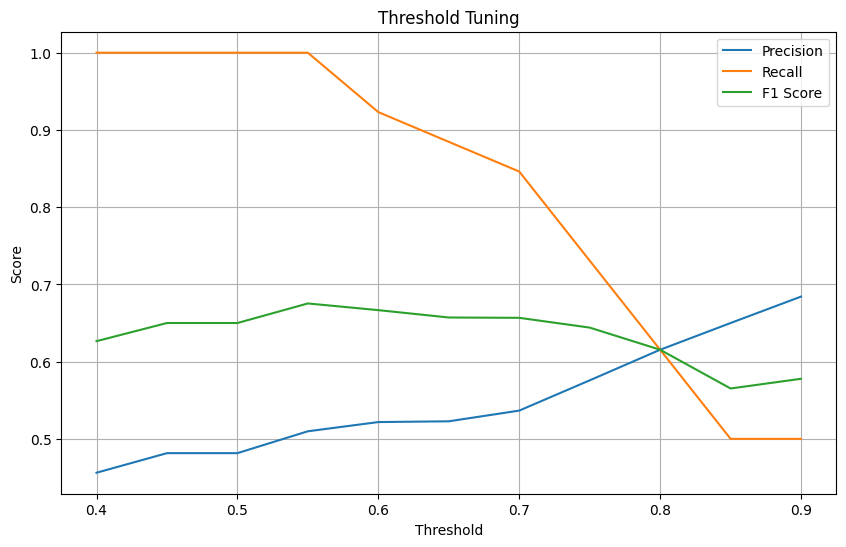

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Replace with your model and test folder
model = tf.keras.models.load_model("../models/patches_model_finetuned.h5")
img_size = 224


test_dir = Path.home() / "Documents" / "duo_patches_dataset" / "split_data" / "test"
test_images = list(test_dir.glob("*/*.jpg"))  # Recursively finds all .jpg images

# Assign label 0 if in 'clean' folder, 1 if in 'faulty' folder
true_labels = [0 if img_path.parent.name.lower() == "clean" else 1 for img_path in test_images]

# N = 2
thresholds = np.arange(0.4, 0.91, 0.05)
precisions, recalls, f1s = [], [], []

def crop_image(img, rows=2, cols=3):
    """Split full keyboard image into patches"""
    img = img.resize((img_size * cols, img_size * rows))
    img = img_to_array(img) / 255.0
    patches = []
    h, w = img.shape[:2]
    ph, pw = h // rows, w // cols
    for i in range(rows):
        for j in range(cols):
            patch = img[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
            patch = tf.image.resize(patch, (img_size, img_size)).numpy()
            patches.append(patch)
    return np.array(patches)

# Run for each threshold
for thresh in thresholds:
    y_pred = []

    for i, img_path in enumerate(test_images):
        img = load_img(img_path)
        patches = crop_image(img)
        preds = model.predict(patches, verbose=0)
        is_faulty = (preds.flatten() > thresh).any()
        # is_faulty = np.sum(preds > threshold) >= N
        y_pred.append(1 if is_faulty else 0)

    y_true = true_labels[:len(y_pred)]
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred)
    f = f1_score(y_true, y_pred)

    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.grid(True)
plt.legend()
plt.show()
